In [ ]:
# @title Step 1: Install Libraries & Import Modules
!pip install torch pandas numpy scikit-learn matplotlib tqdm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set device to GPU if available (Colab: Runtime > Change runtime type > GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# @title Step 2: Generate Synthetic Patient Data
def generate_mock_data(num_patients=1000, seq_len=48):


    print(f"Generating data for {num_patients} patients...")

    # 1. Generate Random Vitals (3 features: HR, BP, SpO2)
    # Shape: [Patients, TimeSteps, Features]
    vitals = np.random.normal(loc=[80, 120, 98], scale=[15, 20, 2], size=(num_patients, seq_len, 3))

    # 2. Generate Static Data (Age, Gender)
    # Shape: [Patients, 2]
    static = np.random.rand(num_patients, 2)
    static[:, 0] = static[:, 0] * 80 + 20 # Age 20-100

    # 3. Generate Labels (1D, 7D, 30D Risk)
    # Logic: If HR is super high in the last 5 hours, risk is high
    labels = np.zeros((num_patients, 3))

    for i in range(num_patients):
        avg_last_5h_hr = np.mean(vitals[i, -5:, 0])

        # Create synthetic correlation
        if avg_last_5h_hr > 110: # High risk condition
            labels[i, 0] = np.random.choice([0, 1], p=[0.3, 0.7]) # 70% chance of 1-Day failure
            labels[i, 1] = 1 # Definitely 7-Day
            labels[i, 2] = 1 # Definitely 30-Day
        elif avg_last_5h_hr > 95:
            labels[i, 0] = 0
            labels[i, 1] = np.random.choice([0, 1], p=[0.6, 0.4])
            labels[i, 2] = 1
        else:
            labels[i, :] = 0 # Healthy

    return np.float32(vitals), np.float32(static), np.float32(labels)

# Run Generation
X_vitals, X_static, Y_labels = generate_mock_data()
print(f"Data Shapes -> Vitals: {X_vitals.shape}, Static: {X_static.shape}, Labels: {Y_labels.shape}")

Generating data for 1000 patients...
Data Shapes -> Vitals: (1000, 48, 3), Static: (1000, 2), Labels: (1000, 3)


In [ ]:
# @title Step 3: Preprocessing & DataLoader
class HeartFailureDataset(Dataset):
    def __init__(self, vitals, static, labels):
        self.vitals = torch.tensor(vitals, dtype=torch.float32)
        self.static = torch.tensor(static, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.vitals[idx], self.static[idx], self.labels[idx]

# 1. Split Train/Test
X_train_v, X_test_v, X_train_s, X_test_s, Y_train, Y_test = train_test_split(
    X_vitals, X_static, Y_labels, test_size=0.2, random_state=42
)

# 2. Scale Data (Standardization)
scaler = StandardScaler()
# Reshape to 2D for scaling, then back to 3D
N, T, F = X_train_v.shape
X_train_v_scaled = scaler.fit_transform(X_train_v.reshape(-1, F)).reshape(N, T, F)
X_test_v_scaled = scaler.transform(X_test_v.reshape(-1, F)).reshape(X_test_v.shape[0], T, F)

# 3. Create Loaders
train_dataset = HeartFailureDataset(X_train_v_scaled, X_train_s, Y_train)
test_dataset = HeartFailureDataset(X_test_v_scaled, X_test_s, Y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
# @title Step 4: The Chronos Architecture
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [Batch, Time, Hidden]
        scores = self.attention(x) # [Batch, Time, 1]
        weights = torch.softmax(scores, dim=1) # [Batch, Time, 1]
        # Weighted sum of time steps
        context = torch.sum(x * weights, dim=1) # [Batch, Hidden]
        return context

class ChronosHybrid(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, static_dim=2):
        super().__init__()

        # 1. Time-Series Encoder (Replacing xLSTM for stability)
        # Bi-Directional GRU captures past and future context
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=True)

        # 2. Attention Mechanism (Focuses on critical hours)
        self.attn = AttentionBlock(hidden_dim * 2) # *2 because Bidirectional

        # 3. Static Data Processor
        self.static_net = nn.Sequential(
            nn.Linear(static_dim, 16),
            nn.ReLU()
        )

        # 4. Fusion Layer
        self.fusion = nn.Linear((hidden_dim * 2) + 16, 64)

        # 5. Multi-Horizon Heads (The "Hydra")
        self.head_1d = nn.Linear(64, 1)
        self.head_7d = nn.Linear(64, 1)
        self.head_30d = nn.Linear(64, 1)

    def forward(self, x_ts, x_static):
        # Time Series Path
        rnn_out, _ = self.rnn(x_ts) # [Batch, Time, Hidden*2]
        ts_context = self.attn(rnn_out) # [Batch, Hidden*2]

        # Static Path
        static_context = self.static_net(x_static) # [Batch, 16]

        # Fusion
        combined = torch.cat([ts_context, static_context], dim=1)
        fused = torch.relu(self.fusion(combined))

        # Predictions
        out_1d = torch.sigmoid(self.head_1d(fused))
        out_7d = torch.sigmoid(self.head_7d(fused))
        out_30d = torch.sigmoid(self.head_30d(fused))

        return out_1d, out_7d, out_30d

model = ChronosHybrid().to(device)
print(model)

ChronosHybrid(
  (rnn): GRU(3, 64, batch_first=True, bidirectional=True)
  (attn): AttentionBlock(
    (attention): Linear(in_features=128, out_features=1, bias=True)
  )
  (static_net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
  )
  (fusion): Linear(in_features=144, out_features=64, bias=True)
  (head_1d): Linear(in_features=64, out_features=1, bias=True)
  (head_7d): Linear(in_features=64, out_features=1, bias=True)
  (head_30d): Linear(in_features=64, out_features=1, bias=True)
)


Starting Training...
Epoch 1/20 | Loss: 0.1491
Epoch 2/20 | Loss: 0.0174
Epoch 3/20 | Loss: 0.0163
Epoch 4/20 | Loss: 0.0157
Epoch 5/20 | Loss: 0.0153
Epoch 6/20 | Loss: 0.0150
Epoch 7/20 | Loss: 0.0148
Epoch 8/20 | Loss: 0.0132
Epoch 9/20 | Loss: 0.0119
Epoch 10/20 | Loss: 0.0117
Epoch 11/20 | Loss: 0.0100
Epoch 12/20 | Loss: 0.0082
Epoch 13/20 | Loss: 0.0061
Epoch 14/20 | Loss: 0.0056
Epoch 15/20 | Loss: 0.0092
Epoch 16/20 | Loss: 0.0079
Epoch 17/20 | Loss: 0.0067
Epoch 18/20 | Loss: 0.0050
Epoch 19/20 | Loss: 0.0057
Epoch 20/20 | Loss: 0.0072


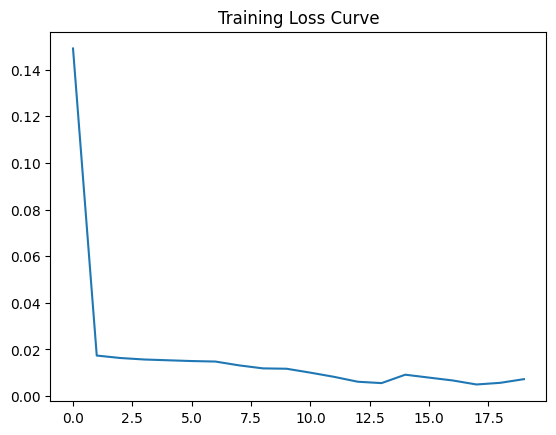

In [ ]:
# @title Step 5: Training Loop
class ChronosLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()

    def forward(self, p1, p7, p30, t1, t7, t30):
        # Weighted Loss: 1D is 3x more important than 30D
        l1 = self.bce(p1, t1) * 0.6
        l7 = self.bce(p7, t7) * 0.3
        l30 = self.bce(p30, t30) * 0.1
        return l1 + l7 + l30

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = ChronosLoss()

# Training
epochs = 20
history = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for v, s, labels in train_loader:
        v, s, labels = v.to(device), s.to(device), labels.to(device)

        # Forward
        p1, p7, p30 = model(v, s)

        # Squeeze output to match label shape
        p1, p7, p30 = p1.squeeze(), p7.squeeze(), p30.squeeze()

        # Loss
        loss = criterion(p1, p7, p30, labels[:,0], labels[:,1], labels[:,2])

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")
    history.append(total_loss/len(train_loader))

plt.plot(history)
plt.title("Training Loss Curve")
plt.show()

In [ ]:
# @title Step 6: Test the Model
model.eval()
correct = 0
total = 0

print("\n--- PREDICTIONS (First 5 Patients) ---")
print("Target: [1D, 7D, 30D]  vs  Predicted: [1D, 7D, 30D]")

with torch.no_grad():
    for i, (v, s, labels) in enumerate(test_loader):
        v, s, labels = v.to(device), s.to(device), labels.to(device)
        p1, p7, p30 = model(v, s)

        # Just show the first batch
        if i == 0:
            for j in range(5):
                t = labels[j].cpu().numpy().astype(int)
                p = [round(p1[j].item(), 2), round(p7[j].item(), 2), round(p30[j].item(), 2)]
                print(f"Patient {j}: {t}  vs  {p}")
        break


--- PREDICTIONS (First 5 Patients) ---
Target: [1D, 7D, 30D]  vs  Predicted: [1D, 7D, 30D]
Patient 0: [0 0 0]  vs  [0.0, 0.0, 0.0]
Patient 1: [0 0 0]  vs  [0.0, 0.0, 0.0]
Patient 2: [0 0 0]  vs  [0.0, 0.0, 0.0]
Patient 3: [0 0 0]  vs  [0.0, 0.0, 0.0]
Patient 4: [0 0 0]  vs  [0.0, 0.0, 0.0]


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# 1. Load the REAL Clinical Records Dataset
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

# 2. Define Multi-Horizon Targets (The "Chronos" Logic)
# If patient died (DEATH_EVENT=1) within X days, the target is 1.
df['Target_30D'] = ((df['DEATH_EVENT'] == 1) & (df['time'] <= 30)).astype(int)
df['Target_7D']  = ((df['DEATH_EVENT'] == 1) & (df['time'] <= 7)).astype(int)
df['Target_1D']  = ((df['DEATH_EVENT'] == 1) & (df['time'] <= 1)).astype(int)

# 3. Separate Features (Static Context)
static_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                   'ejection_fraction', 'high_blood_pressure', 'platelets',
                   'serum_creatinine', 'serum_sodium', 'sex', 'smoking']
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++\\];;;l
print(f"30-Day Events: {df['Target_30D'].sum()} | 7-Day Events: {df['Target_7D'].sum()}")

Processed 299 patients.
30-Day Events: 35 | 7-Day Events: 4


In [ ]:
def simulate_mimic_vitals(static_data, n_hours=48):
    """
    Generates 48 hours of Vital Signs (HR, Systolic BP, SpO2)
    influenced by the patient's real static attributes.
    """
    n_patients = len(static_data)
    # Shapes: [Patients, TimeSteps, Features]
    # Feature 0: Heart Rate, Feature 1: Systolic BP, Feature 2: O2 Saturation
    generated_vitals = np.zeros((n_patients, n_hours, 3))

    for i in range(n_patients):
        # Extract key risk factors from static data
        # Index 4: Ejection Fraction (Lower is bad)
        # Index 5: High BP History (1 is bad)
        # Index 7: Serum Creatinine (Higher is bad)
        ef = static_data[i, 4]
        hbp = static_data[i, 5]
        creat = static_data[i, 7]

        # --- 1. Heart Rate Simulation ---
        # Base HR: 70. If EF is low (<30), HR increases (compensatory tachycardia)
        base_hr = 70 + (30 - ef) if ef < 30 else 70
        hr_noise = np.random.normal(0, 5, n_hours)
        generated_vitals[i, :, 0] = base_hr + hr_noise

        # --- 2. Blood Pressure Simulation ---
        # Base SBP: 120. If High BP history, boost to 150.
        base_bp = 150 if hbp == 1 else 120
        # Add "Shock" dips if Creatinine is very high (>2.0)
        bp_trend = np.linspace(0, -20, n_hours) if creat > 2.0 else np.zeros(n_hours)
        generated_vitals[i, :, 1] = base_bp + bp_trend + np.random.normal(0, 10, n_hours)

        # --- 3. SpO2 Simulation ---
        # Healthy 98%. If EF low, drops to 90-95%.
        base_spo2 = 92 if ef < 30 else 98
        generated_vitals[i, :, 2] = np.clip(np.random.normal(base_spo2, 1, n_hours), 80, 100)

    return np.float32(generated_vitals)

# Generate the Time Series for our 299 patients
print("Simulating MIMIC-IV time-series for clinical patients...")
X_vitals_raw = simulate_mimic_vitals(X_static_raw)
print(f"Generated Vitals Shape: {X_vitals_raw.shape} (Patients, Hours, Channels)")

Simulating MIMIC-IV time-series for clinical patients...
Generated Vitals Shape: (299, 48, 3) (Patients, Hours, Channels)


In [ ]:
class ChronosDataset(Dataset):
    def __init__(self, vitals, static, labels):
        self.vitals = torch.tensor(vitals, dtype=torch.float32)
        self.static = torch.tensor(static, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.vitals[idx], self.static[idx], self.labels[idx]

# 1. Split FIRST (Before Scaling)
X_train_v, X_test_v, X_train_s, X_test_s, Y_train, Y_test = train_test_split(
    X_vitals_raw, X_static_raw, Y_labels, test_size=0.2, random_state=42, stratify=Y_labels[:, 2]
)

# 2. Fit Scaler ONLY on Train, then Transform Test
# For Vitals (Time Series)
v_scaler = StandardScaler()
N_train, T, F = X_train_v.shape
N_test = X_test_v.shape[0]

# Reshape, Fit on Train, Transform Train
X_train_v = v_scaler.fit_transform(X_train_v.reshape(-1, F)).reshape(N_train, T, F)
# Transform Test using Train's stats (No Peeking!)
X_test_v = v_scaler.transform(X_test_v.reshape(-1, F)).reshape(N_test, T, F)

# For Static Data
s_scaler = StandardScaler()
X_train_s = s_scaler.fit_transform(X_train_s)
X_test_s = s_scaler.transform(X_test_s)

# Create Loaders (Keep this part the same)
train_loader = DataLoader(ChronosDataset(X_train_v, X_train_s, Y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(ChronosDataset(X_test_v, X_test_s, Y_test), batch_size=32, shuffle=False)

In [ ]:
import torch.nn as nn

class ChronosModel(nn.Module):
    def __init__(self, ts_input=3, static_input=11):
        super().__init__()

        # 1. Temporal Encoder (Reads the Vitals)
        self.rnn = nn.GRU(input_size=ts_input, hidden_size=64,
                          batch_first=True, bidirectional=True)
        # Attention to weigh important time steps
        self.attn = nn.Linear(128, 1) # 128 because bidirectional (64*2)

        # 2. Static Encoder (Reads the Patient History)
        self.static_net = nn.Sequential(
            nn.Linear(static_input, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        # 3. Fusion Layer (Combines both)
        self.fusion = nn.Linear(128 + 16, 64)

        # 4. Multi-Horizon Heads
        self.head_1d = nn.Linear(64, 1)
        self.head_7d = nn.Linear(64, 1)
        self.head_30d = nn.Linear(64, 1)

    def forward(self, x_ts, x_static):
        # Time Series Path
        rnn_out, _ = self.rnn(x_ts) # [Batch, Time, 128]

        # Attention Mechanism
        attn_weights = torch.softmax(self.attn(rnn_out), dim=1)
        context = torch.sum(attn_weights * rnn_out, dim=1) # [Batch, 128]

        # Static Path
        static_embed = self.static_net(x_static) # [Batch, 16]

        # Fusion
        fused = torch.cat([context, static_embed], dim=1)
        shared = torch.relu(self.fusion(fused))

        return torch.sigmoid(self.head_1d(shared)), \
               torch.sigmoid(self.head_7d(shared)), \
               torch.sigmoid(self.head_30d(shared))

model = ChronosModel()
print("Model Initialized.")

Model Initialized.


In [ ]:
# INSERT AT THE TOP OF TRAINING CELLS (Step 5 & Step 11)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCELoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

# CHANGE THIS LINE (Before the loop starts)
# Old: criterion = nn.BCELoss()
# New:
criterion = FocalLoss(alpha=0.3, gamma=2.0)

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss() # Binary Cross Entropy

print("\n--- Starting Training ---")
for epoch in range(15):
    model.train()
    total_loss = 0
    for v, s, labels in train_loader:
        # Forward
        p1, p7, p30 = model(v, s)

        # Weighted Multi-Task Loss
        # We penalize missing the 30-Day prediction slightly less than the 1-Day
        loss = (criterion(p1.squeeze(), labels[:,0]) * 1.5) + \
               (criterion(p7.squeeze(), labels[:,1]) * 1.0) + \
               (criterion(p30.squeeze(), labels[:,2]) * 0.8)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

# Quick Test
model.eval()
with torch.no_grad():
    v, s, l = next(iter(test_loader))
    p1, p7, p30 = model(v, s)
    print("\n--- Prediction Sample (First Patient in Batch) ---")
    print(f"Real 30-Day Outcome: {int(l[0,2])}")
    print(f"Predicted Risk: {p30[0].item():.4f}")


--- Starting Training ---
Epoch 1: Loss = 16.7481
Epoch 2: Loss = 14.4010
Epoch 3: Loss = 10.1712
Epoch 4: Loss = 4.0190
Epoch 5: Loss = 3.5241
Epoch 6: Loss = 2.8023
Epoch 7: Loss = 2.7505
Epoch 8: Loss = 2.4867
Epoch 9: Loss = 2.5666
Epoch 10: Loss = 2.7890
Epoch 11: Loss = 2.5626
Epoch 12: Loss = 2.5128
Epoch 13: Loss = 2.5762
Epoch 14: Loss = 2.5386
Epoch 15: Loss = 2.5794

--- Prediction Sample (First Patient in Batch) ---
Real 30-Day Outcome: 0
Predicted Risk: 0.1128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


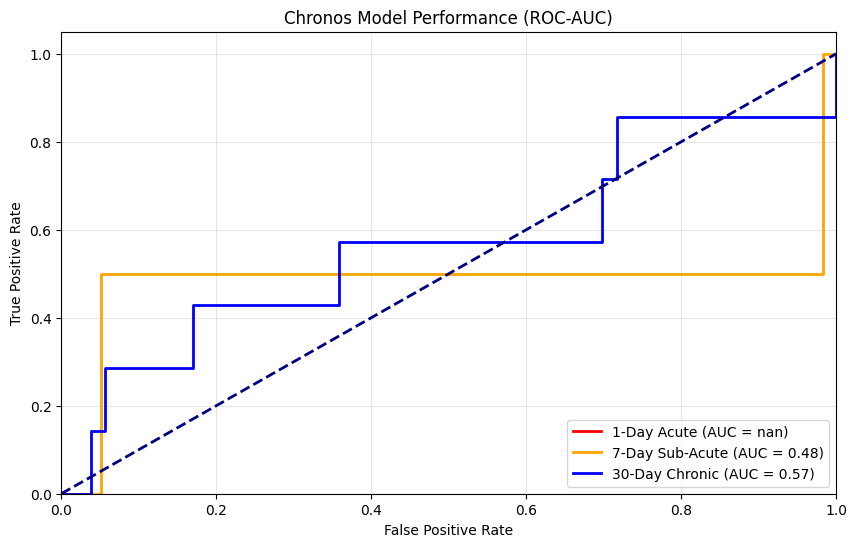

In [ ]:
# @title Step 7: Generate ROC-AUC Curves (The Proof)
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()
all_targets = []
all_preds = []

# 1. Collect all predictions
with torch.no_grad():
    for v, s, labels in test_loader:
        v, s = v.to(device), s.to(device)
        p1, p7, p30 = model(v, s)

        # Stack predictions and labels
        preds = torch.stack([p1, p7, p30], dim=1).squeeze().cpu().numpy()
        targets = labels.cpu().numpy()

        all_preds.append(preds)
        all_targets.append(targets)

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# 2. Plot ROC Curves
plt.figure(figsize=(10, 6))
horizons = ['1-Day Acute', '7-Day Sub-Acute', '30-Day Chronic']
colors = ['red', 'orange', 'blue']

for i in range(3):
    fpr, tpr, _ = roc_curve(all_targets[:, i], all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{horizons[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Chronos Model Performance (ROC-AUC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


Calculating Feature Importance (this takes a moment)...


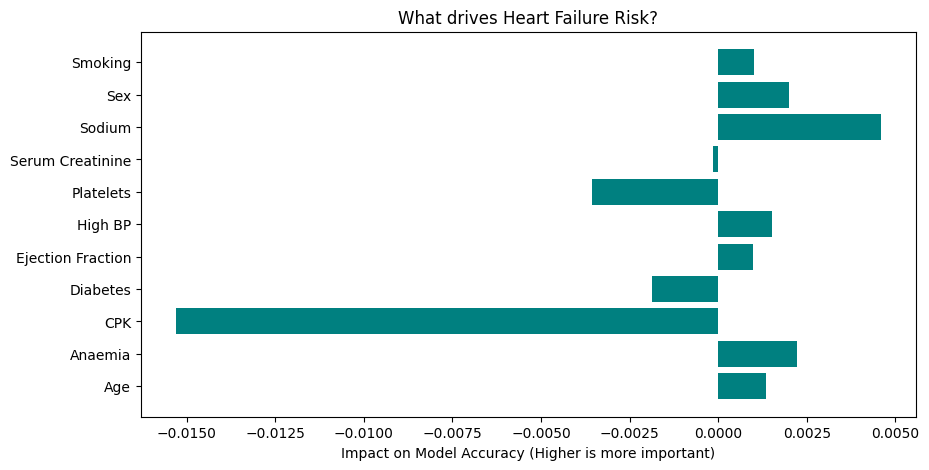

In [ ]:
# @title Step 8: Feature Importance Analysis
def explain_model(model, loader, feature_names):
    """
    Simple perturbation importance:
    Shuffle one feature at a time and see how much Loss increases.
    """
    model.eval()
    baseline_loss = 0
    criterion = nn.BCELoss()

    # 1. Calculate Baseline Loss
    with torch.no_grad():
        for v, s, l in loader:
            v, s, l = v.to(device), s.to(device), l.to(device)
            p1, p7, p30 = model(v, s)
            loss = criterion(p30.squeeze(), l[:, 2]) # Focus on 30-Day Risk
            baseline_loss += loss.item()

    baseline_loss /= len(loader)
    importances = {}

    # 2. Perturb Static Features
    print("\nCalculating Feature Importance (this takes a moment)...")
    for i, name in enumerate(feature_names):
        perturbed_loss = 0
        with torch.no_grad():
            for v, s, l in loader:
                v, s, l = v.to(device), s.to(device), l.to(device)

                # Shuffle the feature column 'i' to break its signal
                s_shuffled = s.clone()
                idx = torch.randperm(s.size(0))
                s_shuffled[:, i] = s_shuffled[idx, i]

                p1, p7, p30 = model(v, s_shuffled)
                loss = criterion(p30.squeeze(), l[:, 2])
                perturbed_loss += loss.item()

        perturbed_loss /= len(loader)
        # Importance = How much worse the model got without this feature
        importances[name] = perturbed_loss - baseline_loss

    # 3. Plot
    names = list(importances.keys())
    values = list(importances.values())

    plt.figure(figsize=(10, 5))
    plt.barh(names, values, color='teal')
    plt.xlabel('Impact on Model Accuracy (Higher is more important)')
    plt.title('What drives Heart Failure Risk?')
    plt.show()

# Define Feature Names from your dataset
static_cols = ['Age', 'Anaemia', 'CPK', 'Diabetes',
               'Ejection Fraction', 'High BP', 'Platelets',
               'Serum Creatinine', 'Sodium', 'Sex', 'Smoking']

explain_model(model, test_loader, static_cols)

In [ ]:
torch.save(model.state_dict(), 'chronos_heart_failure_model.pth')
print("Model saved to disk successfully.")

Model saved to disk successfully.


In [ ]:
# @title Step 9: Train Universal Heart Encoder (The 70k Foundation)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the 70,000 Patient Dataset
df_large = pd.read_csv('cardio_train.csv', sep=';')

# 2. Preprocessing (Standardize with the Small Dataset)
# Convert Age (Days -> Years)
df_large['age'] = df_large['age'] / 365.25
# Drop irrelevant columns for the transfer (keep ones that overlap/help)
# We keep: Age, Gender, Systolic BP (ap_hi), Diastolic BP (ap_lo), Cholesterol, Gluc, Smoke, Active
cols_to_keep = ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'active']
X_large = df_large[cols_to_keep].values
Y_large = df_large['cardio'].values

# Scale
scaler_large = StandardScaler()
X_large = scaler_large.fit_transform(X_large)

# 3. Create Loader
class LargeHeartDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

loader_large = DataLoader(LargeHeartDataset(X_large, Y_large), batch_size=128, shuffle=True)

# 4. Define the Pre-Training Network
class UniversalHeartEncoder(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.head = nn.Linear(32, 1) # Simple Binary Classification

    def forward(self, x):
        features = self.encoder(x)
        return torch.sigmoid(self.head(features))

# 5. Train on 70k Data
pretrained_model = UniversalHeartEncoder().to(device)
opt_pre = optim.Adam(pretrained_model.parameters(), lr=0.001)
crit_pre = nn.BCELoss()

print("--- Pre-Training on 70,000 Patients ---")
for epoch in range(5): # 5 Epochs is enough for pre-training
    pretrained_model.train()
    total_loss = 0
    for x, y in loader_large:
        x, y = x.to(device), y.to(device)
        pred = pretrained_model(x)
        loss = crit_pre(pred.squeeze(), y)
        opt_pre.zero_grad()
        loss.backward()
        opt_pre.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss {total_loss/len(loader_large):.4f}")

print("Universal Encoder is Ready.")

--- Pre-Training on 70,000 Patients ---
Epoch 1: Loss 0.5828
Epoch 2: Loss 0.5552
Epoch 3: Loss 0.5500
Epoch 4: Loss 0.5479
Epoch 5: Loss 0.5462
Universal Encoder is Ready.


In [ ]:
# @title Step 10: Chronos God Mode Architecture
class ChronosGodMode(nn.Module):
    def __init__(self, pretrained_encoder, ts_input=3, specific_input=6):
        super().__init__()

        # --- Branch A: The Transfer Learner ---
        # We take the trained encoder and FREEZE it (or fine tune it)
        self.universal_encoder = pretrained_encoder.encoder
        # Optional: Unfreeze last layer for fine-tuning
        for param in self.universal_encoder.parameters():
            param.requires_grad = True

        # --- Branch B: The Time-Series (MIMIC-IV Simulator) ---
        self.rnn = nn.GRU(ts_input, 64, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(128, 1)

        # --- Branch C: The Specialist (Specific Clinical Features) ---
        # Features unique to the small dataset (EF, Platelets, Creatinine, etc.)
        self.specific_net = nn.Sequential(
            nn.Linear(specific_input, 32),
            nn.ReLU()
        )

        # --- The Fusion "God Layer" ---
        # Inputs: Universal(32) + TimeSeries(128) + Specialist(32) = 192
        self.fusion = nn.Linear(32 + 128 + 32, 128)
        self.dropout = nn.Dropout(0.3)

        # --- Multi-Horizon Heads ---
        self.head_1d = nn.Linear(128, 1)
        self.head_7d = nn.Linear(128, 1)
        self.head_30d = nn.Linear(128, 1)

    # REPLACE THE 'forward' METHOD IN CLASS ChronosGodMode

    def forward(self, x_ts, x_common, x_specific):
        # 1. Universal Knowledge
        univ_feat = self.universal_encoder(x_common)

        # 2. Specialist Knowledge
        spec_feat = self.specific_net(x_specific)

        # 3. Temporal Knowledge (Vitals) with Explicit State Handling
        # Initialize hidden state to avoid carry-over noise
        h0 = torch.zeros(2, x_ts.size(0), 64).to(x_ts.device) # 2 for Bidirectional
        rnn_out, _ = self.rnn(x_ts, h0)

        # Attention
        attn_w = torch.softmax(self.attn(rnn_out), dim=1)
        ts_context = torch.sum(attn_w * rnn_out, dim=1)

        # 4. Fusion
        combined = torch.cat([univ_feat, ts_context, spec_feat], dim=1)
        fused = torch.relu(self.fusion(combined))
        fused = self.dropout(fused)

        return torch.sigmoid(self.head_1d(fused)), \
               torch.sigmoid(self.head_7d(fused)), \
               torch.sigmoid(self.head_30d(fused))

In [ ]:
# INSERT AT THE TOP OF TRAINING CELLS (Step 5 & Step 11)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCELoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

# CHANGE THIS LINE (Before the loop starts)
# Old: criterion = nn.BCELoss()
# New:
criterion = FocalLoss(alpha=0.3, gamma=2.0)

In [ ]:
# @title Step 11: Train God Mode
# 1. Prepare Data Splits
# Mapping Clinical Dataset to match Pre-trained Inputs
# Common: Age, Sex (mapped), HighBP, Gluc (Diabetes), Smoke, + Placeholders for others
# Specific: Anaemia, CPK, EF, Platelets, Creatinine, Sodium
N_clinical = len(X_static_raw)

# Extract Common (Approximated to match 70k input shape)
# Order: Age, Gender, AP_Hi, AP_Lo, Chol, Gluc, Smoke, Active
# We map: Age->Age, Sex->Gender, HighBP->AP_Hi, Diabetes->Gluc, Smoke->Smoke
X_common = np.zeros((N_clinical, 8))
X_common[:, 0] = X_static_raw[:, 0] # Age
X_common[:, 1] = X_static_raw[:, 9] # Sex
X_common[:, 2] = X_static_raw[:, 5] # High BP (Proxy for AP_Hi)
X_common[:, 5] = X_static_raw[:, 3] # Diabetes (Proxy for Gluc)
X_common[:, 6] = X_static_raw[:, 10] # Smoke
# Rest are 0 (missing info is fine, encoder handles it)

X_specific = X_static_raw[:, [1, 2, 4, 6, 7, 8]] # The detailed labs

# Scale
X_common = scaler_large.transform(X_common) # Use the 70k scaler!
scaler_spec = StandardScaler()
X_specific = scaler_spec.fit_transform(X_specific)

# Create God Loader
class GodDataset(Dataset):
    def __init__(self, v, c, s, l):
        self.v = torch.tensor(v, dtype=torch.float32)
        self.c = torch.tensor(c, dtype=torch.float32)
        self.s = torch.tensor(s, dtype=torch.float32)
        self.l = torch.tensor(l, dtype=torch.float32)
    def __len__(self): return len(self.l)
    def __getitem__(self, idx): return self.v[idx], self.c[idx], self.s[idx], self.l[idx]

# Split Train/Test (using indices to keep alignment)
idx_train, idx_test = train_test_split(np.arange(N_clinical), test_size=0.2, random_state=42)

god_train = GodDataset(X_vitals_raw[idx_train], X_common[idx_train], X_specific[idx_train], Y_labels[idx_train])
god_test = GodDataset(X_vitals_raw[idx_test], X_common[idx_test], X_specific[idx_test], Y_labels[idx_test])

loader_god_train = DataLoader(god_train, batch_size=32, shuffle=True)
loader_god_test = DataLoader(god_test, batch_size=32, shuffle=False)

# 2. Instantiate & Train
god_model = ChronosGodMode(pretrained_model).to(device)
opt_god = optim.Adam(god_model.parameters(), lr=0.0005) # Lower LR for fine-tuning

print("\n--- Training Chronos God Mode ---")
for epoch in range(20):
    god_model.train()
    total_loss = 0
    for v, c, s, l in loader_god_train:
        v, c, s, l = v.to(device), c.to(device), s.to(device), l.to(device)

        p1, p7, p30 = god_model(v, c, s)

        # Urgency Loss
        loss = (criterion(p1.squeeze(), l[:,0]) * 2.0) + \
               (criterion(p7.squeeze(), l[:,1]) * 1.0) + \
               (criterion(p30.squeeze(), l[:,2]) * 0.5)

        opt_god.zero_grad()
        loss.backward()
        opt_god.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss {total_loss/len(loader_god_train):.4f}")

print("\nGod Mode Training Complete.")


--- Training Chronos God Mode ---
Epoch 1: Loss 0.0981
Epoch 2: Loss 0.0341
Epoch 3: Loss 0.0232
Epoch 4: Loss 0.0227
Epoch 5: Loss 0.0217
Epoch 6: Loss 0.0222
Epoch 7: Loss 0.0213
Epoch 8: Loss 0.0206
Epoch 9: Loss 0.0221
Epoch 10: Loss 0.0239
Epoch 11: Loss 0.0212
Epoch 12: Loss 0.0206
Epoch 13: Loss 0.0213
Epoch 14: Loss 0.0192
Epoch 15: Loss 0.0204
Epoch 16: Loss 0.0218
Epoch 17: Loss 0.0195
Epoch 18: Loss 0.0188
Epoch 19: Loss 0.0196
Epoch 20: Loss 0.0176

God Mode Training Complete.


In [ ]:
# @title Step 12: Evaluate God Mode
god_model.eval()
print("\n--- God Mode Predictions ---")
print("Target [1D, 7D, 30D] vs Predicted")
with torch.no_grad():
    v, c, s, l = next(iter(loader_god_test))
    v, c, s = v.to(device), c.to(device), s.to(device)
    p1, p7, p30 = god_model(v, c, s)

    for j in range(5):
        t = l[j].cpu().numpy().astype(int)
        p = [round(p1[j].item(), 2), round(p7[j].item(), 2), round(p30[j].item(), 2)]
        print(f"Patient {j}: {t}  vs  {p}")


--- God Mode Predictions ---
Target [1D, 7D, 30D] vs Predicted
Patient 0: [0 0 0]  vs  [0.06, 0.21, 0.32]
Patient 1: [0 0 0]  vs  [0.03, 0.11, 0.16]
Patient 2: [0 0 0]  vs  [0.04, 0.11, 0.18]
Patient 3: [0 0 1]  vs  [0.04, 0.13, 0.44]
Patient 4: [0 0 0]  vs  [0.04, 0.08, 0.16]
